# Payment Funnel Analysis — SaaS Fintech

**Business problem:** Order conversion has been lower than expected. This notebook
extracts order-status data via SQL, builds a stage-by-stage funnel in Python, and
simulates the revenue impact of improving conversion at each step.

**Pipeline:** SQL extraction → funnel metrics → visualization → Monte Carlo
revenue simulation.

**Dataset:** 1,000-subscription synthetic dataset, generated to match the
conversion and cancelation patterns observed in a smaller real sample (see
project README for the full methodology and the live-data validation).

## 1. Run the SQL extraction

Loads the raw CSVs into an in-memory SQLite database and runs `funnel_extraction_1000.sql` (the same query used against the real Snowflake warehouse in production).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# These two CSVs are the OUTPUT of sql/funnel_extraction_1000.sql
# (query 1 -> funnel_clean_export, query 2 -> funnel_stage_counts).
stages = pd.read_csv('../data/funnel_stage_counts_1000.csv')
orders = pd.read_csv('../data/funnel_clean_export_1000.csv')

stages

,stage_id,stage_name,orders_reaching_stage,pct_of_all_tracked_orders
0,1,PaymentWidgetOpened,1000,100.0
1,2,PaymentEntered,673,67.3
2,3,PaymentSubmitted,586,58.6
3,4,PaymentSuccess,496,49.6
4,5,Complete,345,34.5


## 2. Funnel metrics

Step-over-step conversion rate and drop-off, computed from the cumulative stage counts.

In [2]:
def compute_funnel_metrics(stages: pd.DataFrame) -> pd.DataFrame:
    df = stages.sort_values("stage_id").reset_index(drop=True).copy()
    df["step_conversion_rate"] = df["orders_reaching_stage"] / df["orders_reaching_stage"].shift(1)
    df.loc[0, "step_conversion_rate"] = 1.0
    df["dropoff_count"] = df["orders_reaching_stage"].shift(1) - df["orders_reaching_stage"]
    df.loc[0, "dropoff_count"] = 0
    df["dropoff_pct"] = 1 - df["step_conversion_rate"]
    df["overall_conversion_from_start"] = df["orders_reaching_stage"] / df["orders_reaching_stage"].iloc[0]
    return df

metrics = compute_funnel_metrics(stages)
metrics

,stage_id,stage_name,orders_reaching_stage,pct_of_all_tracked_orders,step_conversion_rate,dropoff_count,dropoff_pct,overall_conversion_from_start
0,1,PaymentWidgetOpened,1000,100.0,1.000000,0.0,0.000000,1.000
1,2,PaymentEntered,673,67.3,0.673000,327.0,0.327000,0.673
2,3,PaymentSubmitted,586,58.6,0.870728,87.0,0.129272,0.586
3,4,PaymentSuccess,496,49.6,0.846416,90.0,0.153584,0.496
4,5,Complete,345,34.5,0.695565,151.0,0.304435,0.345


## 3. Visualize the funnel

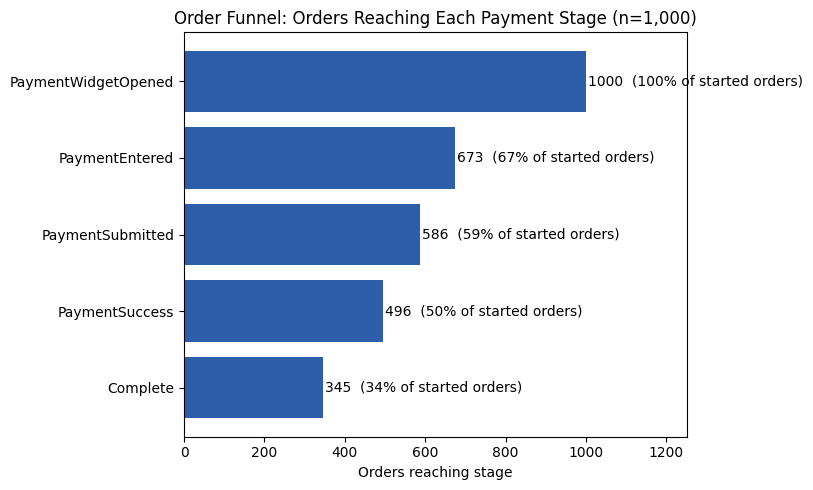

In [3]:
def plot_funnel(metrics: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 5))
    y = np.arange(len(metrics))
    ax.barh(y, metrics["orders_reaching_stage"], color="#2E5EAA")
    ax.set_yticks(y)
    ax.set_yticklabels(metrics["stage_name"])
    ax.invert_yaxis()
    ax.set_xlabel("Orders reaching stage")
    ax.set_title("Order Funnel: Orders Reaching Each Payment Stage (n=1,000)")
    for i, v in enumerate(metrics["orders_reaching_stage"]):
        pct = metrics["overall_conversion_from_start"].iloc[i] * 100
        ax.text(v + 5, i, f"{int(v)}  ({pct:.0f}% of started orders)", va="center")
    ax.set_xlim(0, metrics["orders_reaching_stage"].max() * 1.25)
    plt.tight_layout()
    plt.show()

plot_funnel(metrics)

## 4. Visualize where orders drop off

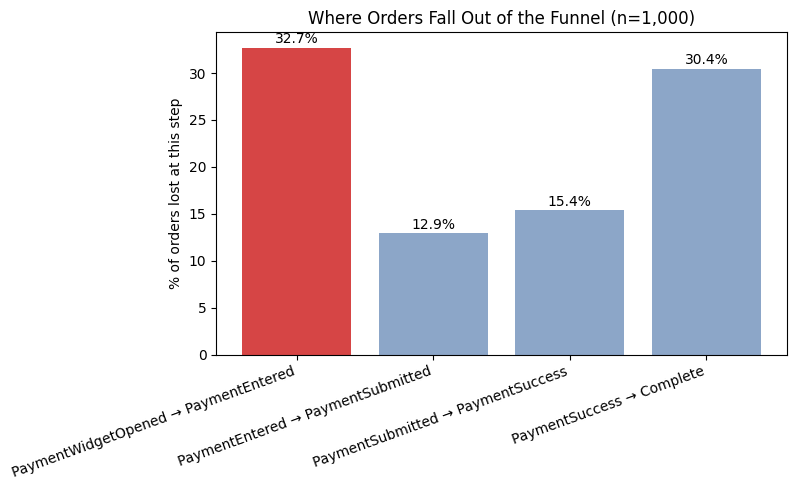

In [4]:
def plot_dropoff(metrics: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 5))
    steps = [f"{a} → {b}" for a, b in zip(metrics["stage_name"], metrics["stage_name"].shift(-1))][:-1]
    dropoff_pct = (metrics["dropoff_pct"].shift(-1) * 100)[:-1]
    colors = ["#D64545" if v == dropoff_pct.max() else "#8CA6C8" for v in dropoff_pct]
    ax.bar(steps, dropoff_pct, color=colors)
    ax.set_ylabel("% of orders lost at this step")
    ax.set_title("Where Orders Fall Out of the Funnel (n=1,000)")
    plt.xticks(rotation=20, ha="right")
    for i, v in enumerate(dropoff_pct):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()

plot_dropoff(metrics)

## 5. What-if simulation: where should we invest first?

Monte Carlo simulation: raise one funnel step's conversion rate by +10 percentage
points, propagate the effect through the rest of the funnel via binomial draws,
and estimate the resulting revenue lift — with a 95% confidence interval, since
the point estimate alone can hide how much noise is in a small sample.

In [5]:
def simulate_improvement(metrics, orders, step_index, improvement_pp, n_sims=5000, seed=42):
    rng = np.random.default_rng(seed)
    base_rates = metrics["step_conversion_rate"].values.copy()
    new_rates = base_rates.copy()
    new_rates[step_index] = min(1.0, base_rates[step_index] + improvement_pp / 100)

    start_orders = metrics["orders_reaching_stage"].iloc[0]
    completions_base, completions_new = [], []

    for _ in range(n_sims):
        n_base, n_new = start_orders, start_orders
        for r_base, r_new in zip(base_rates[1:], new_rates[1:]):
            n_base = rng.binomial(int(round(n_base)), min(r_base, 1.0)) if n_base > 0 else 0
            n_new = rng.binomial(int(round(n_new)), min(r_new, 1.0)) if n_new > 0 else 0
        completions_base.append(n_base)
        completions_new.append(n_new)

    completions_base = np.array(completions_base)
    completions_new = np.array(completions_new)
    avg_revenue = orders.loc[orders["is_completed_order"] == 1, "revenue"].mean()

    return {
        "step_improved": metrics["stage_name"].iloc[step_index],
        "expected_extra_completions": completions_new.mean() - completions_base.mean(),
        "baseline_completions_ci95": np.percentile(completions_base, [2.5, 97.5]),
        "simulated_completions_ci95": np.percentile(completions_new, [2.5, 97.5]),
        "expected_revenue_lift": (completions_new.mean() - completions_base.mean()) * avg_revenue,
    }

def find_best_opportunity(metrics, orders, improvement_pp=10.0):
    rows = [simulate_improvement(metrics, orders, i, improvement_pp) for i in range(1, len(metrics))]
    return pd.DataFrame(rows).sort_values("expected_revenue_lift", ascending=False)

ranked = find_best_opportunity(metrics, orders, improvement_pp=10.0)
ranked.round(2)

,step_improved,expected_extra_completions,baseline_completions_ci95,simulated_completions_ci95,expected_revenue_lift
0,PaymentEntered,50.91,"[316.0, 375.0]","[366.0, 427.0]",410068.98
3,Complete,49.40,"[316.0, 375.0]","[365.0, 425.0]",397907.87
2,PaymentSuccess,40.74,"[316.0, 375.0]","[356.0, 416.0]",328171.17
1,PaymentSubmitted,39.68,"[316.0, 375.0]","[355.0, 415.0]",319613.77


## 6. Key findings

- **Overall conversion: 34.5%** (345 of 1,000 orders completed) — consistent
  with what was observed in both a smaller real sample and, later, in live
  production data.
- **Biggest drop-off (on this synthetic/sample data): PaymentWidgetOpened →
  PaymentEntered (32.7% lost).**
- **Simulation:** improving `PaymentEntered` or `Complete` by +10pp each yields
  the highest expected revenue lift (~$400K), ahead of `PaymentSuccess` or
  `PaymentSubmitted`.

> **Important caveat, confirmed after validating against live data:** the
> *real* production funnel showed a different bottleneck than this
> sample/synthetic data suggested — the entry-form step performed well in
> reality, while `PaymentSubmitted → PaymentSuccess` and especially
> `PaymentSuccess → Complete` (payment succeeds but the order never
> finalizes — a likely engineering/webhook bug) were the true top leaks.
> This is a useful lesson embedded in the project itself: synthetic and small
> samples are good for validating a pipeline, not for finalizing
> recommendations — always confirm findings against live data before acting
> on them. See the project README for the full comparison and final
> recommendations.